In [1]:
# /usr/bin/env python3
# -*- coding: utf-8 -*-
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.style.use('../../black_white.mplstyle')

## Ломаная линия

Простейшая точечно-заданная линия называется *ломанной линией*. Она состоит из отрезков, последовательно соединяющих заданные точки. Значения параметра в каждой последующей точке $t_i < t_{i+1}$. Радиус вектор ломанной определяется равенством.
\begin{equation}
    \mathbf{r}(t) = \mathbf{p}_i (1-w) + \mathbf{p}_{i+1} w, \;\; w = \dfrac{t-t_i}{t_{i+1} - t_{i}},\;\; t_0 \leq t \leq t_n
\end{equation}

In [3]:
# Пример 5-2 из учебника Роджерс, Адамс «Математические основы машинной графики»
P = [(0, 0), (1, 1), (2, -1), (3, 0)]
P = np.array(P, dtype=np.float64)

In [4]:
def chain_v1(P: np.ndarray) -> np.ndarray:
    """Точки ломанной линии, соединяющей опорные точки P
    Реализованна без использования циклов"""
    N = 10
    t = np.linspace(0.0, 1.0, N)
    k = P.shape[0] - 1
    # tile создает новый массив, тратя память и время
    # поэтому функция с циклом получается эффективнее и понятнее
    # наверняка можно это переделать получше
    res  = P[:-1].repeat(N, 0) * (1.0 - np.tile(t, k)[:, np.newaxis])
    res += P[1:].repeat(N, 0) * np.tile(t, k)[:, np.newaxis]
    return res

In [5]:
def chain_v2(P: np.ndarray) -> np.ndarray:
    """Точки ломанной линии, соединяющей опорные точки P
    Реализованна с использованием циклов"""
    res = []
    N = 10
    w = np.linspace(0.0, 1.0, N)
    for p1, p2 in zip(P[:-1], P[1:]):
        # Параметр w пробегает значения из отрезка [0, 1]
        res.append(p1 * (1-w[:, np.newaxis]) + p2 * w[:, np.newaxis])
    return np.array(res)

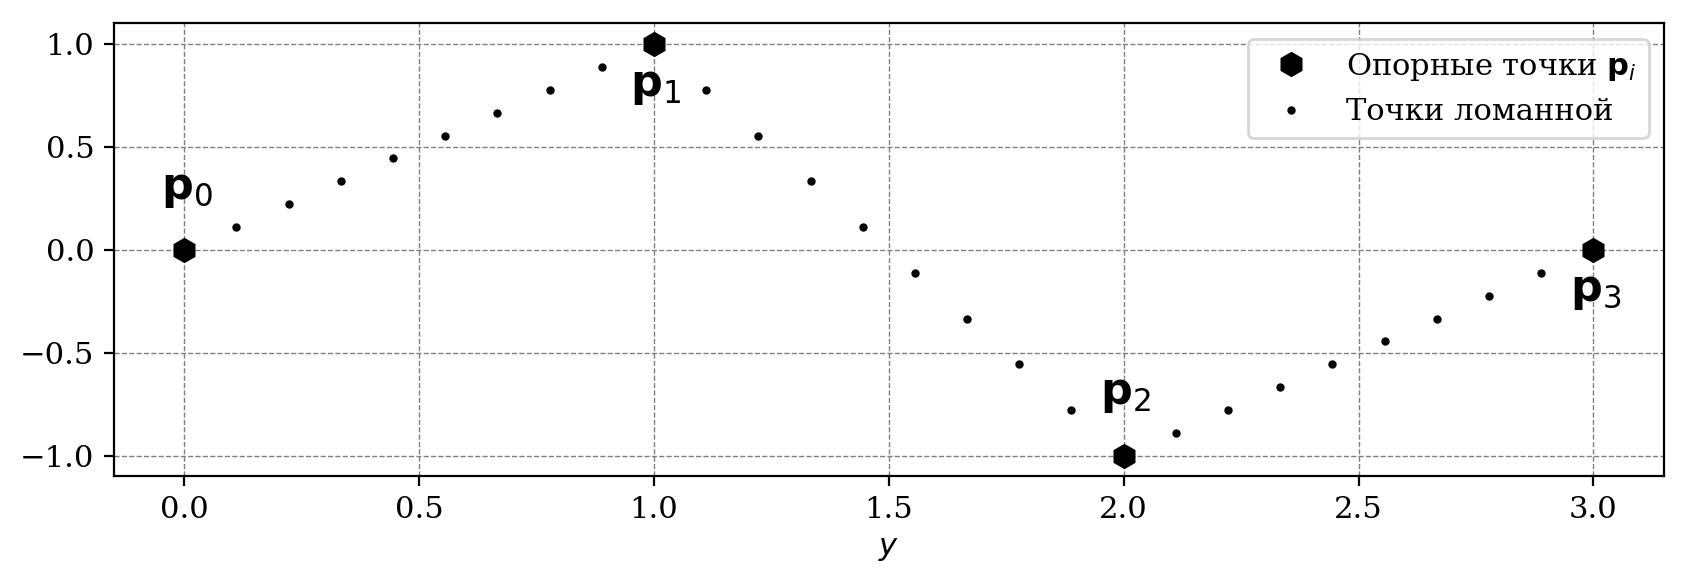

In [6]:
fig1 = plt.figure(1, figsize=(10, 3))
ax1 = fig1.add_subplot(1,1,1)

x, y = chain_v1(P).T

ax1.plot(P.T[0], P.T[1], ls='None', marker='h', markersize=8, label=r'Опорные точки $\mathbf{p}_{i}$')
ax1.plot(x, y, ls='None', marker='o', markersize=2, markerfacecolor='k', label='Точки ломанной')

# Обозначение точек P1, P2, P3, P4
for i, point in enumerate(P):
    # нужно чередование сверху/снизу
    ax1.text(*point-np.array([0.05, 0.25 * (-1)**(i+1)]), s='$\mathbf{{p}}_{0}$'.format(i), fontsize=16)

ax1.set_xlabel(r'$x$')
ax1.set_xlabel(r'$y$')
ax1.legend(loc='best')

In [7]:
print('Точки ломанной для ' + ', '.join(["$\mathbf{{p}}_{0} = ({1[0]}, {1[1]})^T$".format(i, p) for i, p in enumerate(P)]))

Точки ломанной для $\mathbf{p}_0 = (0.0, 0.0)^T$, $\mathbf{p}_1 = (1.0, 1.0)^T$, $\mathbf{p}_2 = (2.0, -1.0)^T$, $\mathbf{p}_3 = (3.0, 0.0)^T$


In [8]:
fig1.savefig('img01.pdf', format='pdf', bbox_inches='tight', pad_inches=0.0)